###БЛОК 1: УСТАНОВКА И ИМПОРТ БИБЛИОТЕК

In [1]:
# Установка дополнительных библиотек
!pip install wordcloud nltk scikit-learn matplotlib seaborn pandas numpy -q
!pip install spacy
!python -m spacy download en_core_web_sm

# Загрузка ресурсов NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✅ Все библиотеки установлены!")

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re

# Настройка графиков
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Все библиотеки импортированы!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 76.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Все библиотеки установлены!
✅ Все библиотеки импортированы!


###БЛОК 2: ЗАГРУЗКА ДАТАСЕТА IMDB

In [2]:
from datasets import load_dataset
import pandas as pd

# Загрузка IMDB через Hugging Face
print(" Загрузка датасета IMDB...")

# ВАРИАНТ 1: Официальный IMDB от Stanford NLP
dataset = load_dataset("stanfordnlp/imdb")

# Конвертация в DataFrame
df = dataset['train'].to_pandas()

print(f" Загружено {len(df)} отзывов")
print(f"\n Структура данных:")
print(df.head())

print(f"\n Распределение классов:")
print(df['label'].value_counts())
print("\n0 = Negative, 1 = Positive")

 Загрузка датасета IMDB...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

 Загружено 25000 отзывов

 Структура данных:
                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0

 Распределение классов:
label
0    12500
1    12500
Name: count, dtype: int64

0 = Negative, 1 = Positive


###БЛОК 3: Статистика и визуализация длин текстов

БЛОК 3: СТАТИСТИКА И ВИЗУАЛИЗАЦИЯ ДЛИН ТЕКСТОВ

📏 Статистика длин текстов:
  Средняя длина (символы): 1325
  Средняя длина (слова): 234
  Мин: 52, Макс: 13704


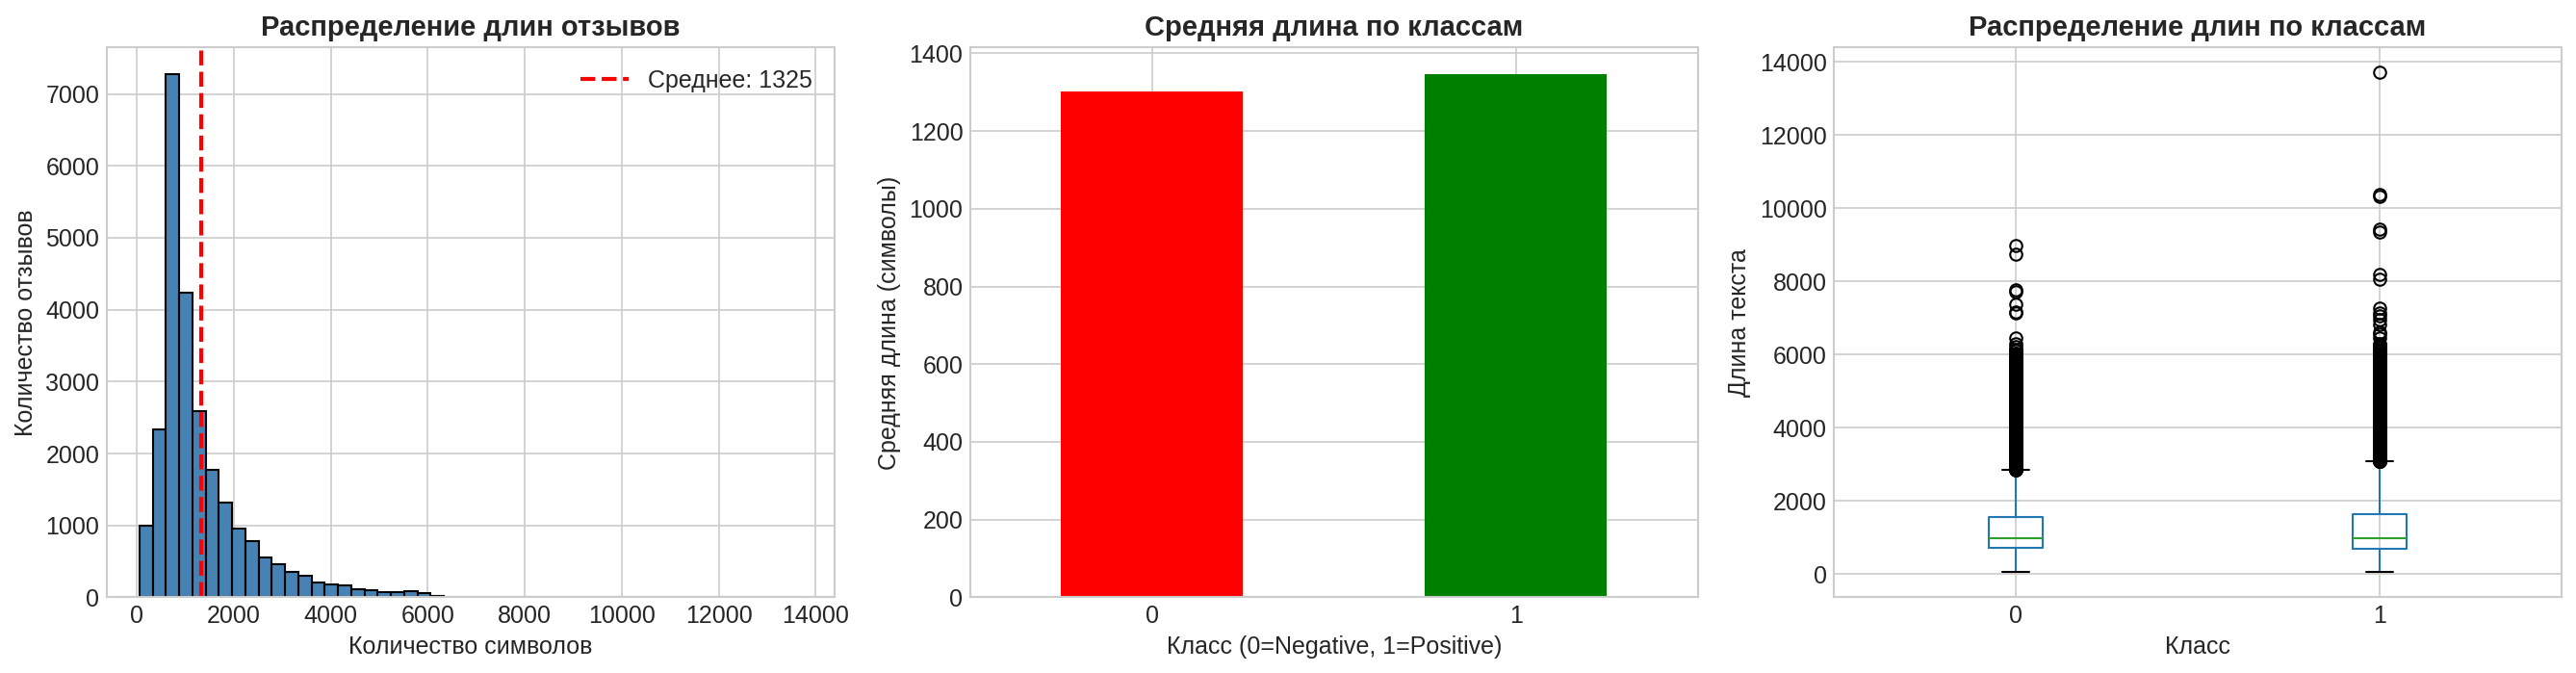

✅ График сохранён: figure_4_1_text_lengths.png


In [3]:
print("="*60)
print("БЛОК 3: СТАТИСТИКА И ВИЗУАЛИЗАЦИЯ ДЛИН ТЕКСТОВ")
print("="*60)

# Добавляем колонку с длиной текста
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print(f"\n📏 Статистика длин текстов:")
print(f"  Средняя длина (символы): {df['text_length'].mean():.0f}")
print(f"  Средняя длина (слова): {df['word_count'].mean():.0f}")
print(f"  Мин: {df['text_length'].min()}, Макс: {df['text_length'].max()}")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма длин
axes[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Среднее: {df["text_length"].mean():.0f}')
axes[0].set_title('Распределение длин отзывов', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Количество символов')
axes[0].set_ylabel('Количество отзывов')
axes[0].legend()

# Распределение по классам
df.groupby('label')['text_length'].mean().plot(kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Средняя длина по классам', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Класс (0=Negative, 1=Positive)')
axes[1].set_ylabel('Средняя длина (символы)')
axes[1].tick_params(axis='x', rotation=0)

# Boxplot
df.boxplot(column='text_length', by='label', ax=axes[2])
axes[2].set_title('Распределение длин по классам', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Класс')
axes[2].set_ylabel('Длина текста')
plt.suptitle('')

plt.tight_layout()
plt.savefig('figure_4_1_text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ График сохранён: figure_4_1_text_lengths.png")

###БЛОК 4: ОЧИСТКА ТЕКСТА

In [4]:
print("\n" + "="*60)
print("БЛОК 4: ОЧИСТКА ТЕКСТА")
print("="*60)

def clean_text(text):
    """Очистка текста: нижний регистр, удаление HTML-тегов, пунктуации"""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)  # Удаление HTML-тегов
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Оставляем только буквы
    text = re.sub(r'\s+', ' ', text).strip()  # Удаление лишних пробелов
    return text

df['text_clean'] = df['text'].apply(clean_text)

print("Примеры очистки:")
for i in range(3):
    print(f"\n{i+1}. Оригинал: {df['text'].iloc[i][:100]}...")
    print(f"   Очищено: {df['text_clean'].iloc[i][:100]}...")


БЛОК 4: ОЧИСТКА ТЕКСТА
Примеры очистки:

1. Оригинал: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w...
   Очищено: i rented i am curiousyellow from my video store because of all the controversy that surrounded it wh...

2. Оригинал: "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's poli...
   Очищено: i am curious yellow is a risible and pretentious steaming pile it doesnt matter what ones political ...

3. Оригинал: If only to avoid making this type of film in the future. This film is interesting as an experiment b...
   Очищено: if only to avoid making this type of film in the future this film is interesting as an experiment bu...


###БЛОК 5: УДАЛЕНИЕ СТОП-СЛОВ

In [5]:
print("\n" + "="*60)
print("БЛОК 5: УДАЛЕНИЕ СТОП-СЛОВ")
print("="*60)

english_stopwords = set(stopwords.words('english'))
# ДОБАВЛЯЕМ "was" и "had" в стоп-слова, чтобы они не лемматизировались!
english_stopwords.update(['was', 'were', 'had', 'has', 'have', 'being', 'been'])

print(f"Загружено {len(english_stopwords)} английских стоп-слов")

def remove_stopwords(text):
    """Удаление стоп-слов"""
    words = text.split()
    filtered = [w for w in words if w not in english_stopwords]
    return ' '.join(filtered)

df['text_no_stopwords'] = df['text_clean'].apply(remove_stopwords)

print("\nПримеры:")
for i in range(3):
    print(f"\n{i+1}. До: {df['text_clean'].iloc[i][:80]}...")
    print(f"   После: {df['text_no_stopwords'].iloc[i][:80]}...")


БЛОК 5: УДАЛЕНИЕ СТОП-СЛОВ
Загружено 198 английских стоп-слов

Примеры:

1. До: i rented i am curiousyellow from my video store because of all the controversy t...
   После: rented curiousyellow video store controversy surrounded first released also hear...

2. До: i am curious yellow is a risible and pretentious steaming pile it doesnt matter ...
   После: curious yellow risible pretentious steaming pile doesnt matter ones political vi...

3. До: if only to avoid making this type of film in the future this film is interesting...
   После: avoid making type film future film interesting experiment tells cogent storyone ...


###БЛОК 6: ЛЕММАТИЗАЦИЯ

In [6]:
import spacy
# Загрузка модели
try:
    nlp = spacy.load("en_core_web_sm")
    print("✅ Модель spaCy успешно загружена!")
except OSError:
    print("⚠️ Модель не найдена. Скачиваем...")
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")
    print("✅ Модель скачана и загружена!")

# ПРОСТАЯ обработка
print("\n" + "="*60)
print("БЛОК 6: ЛЕММАТИЗАЦИЯ (spaCy)")
print("="*60)
print("\nОбработка текстов...")

lemmas_list = []
for idx, text in enumerate(df['text_no_stopwords']):
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc if not token.is_space]
    lemmas_list.append(' '.join(lemmas))

    # Прогресс каждые 5000 отзывов
    if (idx + 1) % 5000 == 0:
        print(f"  Обработано: {idx + 1}/25000")

df['text_lemmas'] = lemmas_list

print(" Лемматизация завершена!")
print("\nПримеры лемматизации (spaCy):")
for i in range(3):
    print(f"\n{i+1}. До: {df['text_no_stopwords'].iloc[i][:80]}...")
    print(f"   После: {df['text_lemmas'].iloc[i][:80]}...")

✅ Модель spaCy успешно загружена!

БЛОК 6: ЛЕММАТИЗАЦИЯ (spaCy)

Обработка текстов...
  Обработано: 5000/25000
  Обработано: 10000/25000
  Обработано: 15000/25000
  Обработано: 20000/25000
  Обработано: 25000/25000
 Лемматизация завершена!

Примеры лемматизации (spaCy):

1. До: rented curiousyellow video store controversy surrounded first released also hear...
   После: rent curiousyellow video store controversy surround first release also heard fir...

2. До: curious yellow risible pretentious steaming pile doesnt matter ones political vi...
   После: curious yellow risible pretentious steaming pile do not matter one political vie...

3. До: avoid making type film future film interesting experiment tells cogent storyone ...
   После: avoid make type film future film interesting experiment tell cogent storyone mig...


###БЛОК 7: ЧАСТОТНЫЙ АНАЛИЗ (ТОП-10 СЛОВ)


БЛОК 7: ЧАСТОТНЫЙ АНАЛИЗ
Топ-10 слов в НЕГАТИВНЫХ отзывах:
  movie: 27809
  film: 21781
  not: 20752
  one: 12812
  make: 12035
  do: 11724
  like: 11709
  see: 10966
  bad: 10257
  get: 9453

Топ-10 слов в ПОЗИТИВНЫХ отзывах:
  film: 24292
  movie: 21795
  not: 14063
  one: 13505
  see: 12077
  good: 10741
  make: 10206
  like: 9827
  well: 8757
  do: 8374


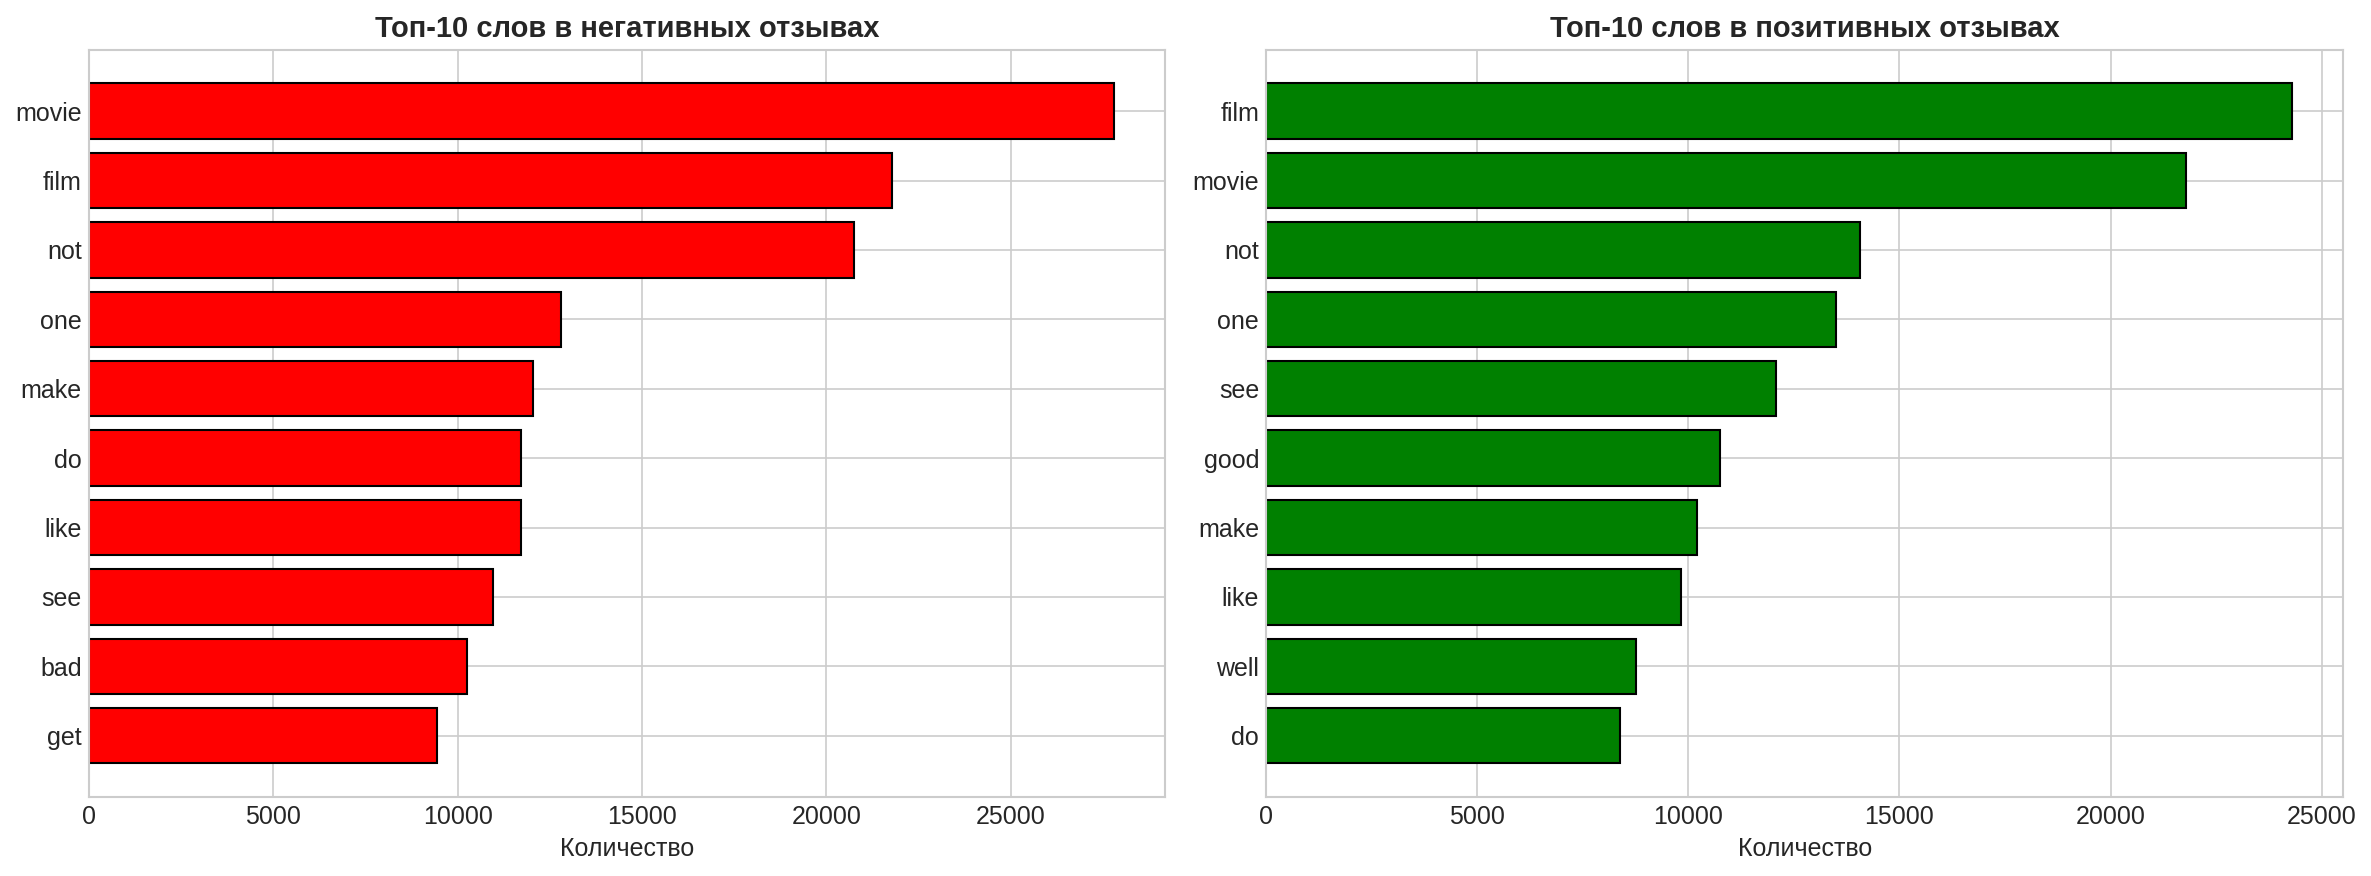

✅ График сохранён: figure_4_5_top_words_corrected.png


In [7]:
print("\n" + "="*60)
print("БЛОК 7: ЧАСТОТНЫЙ АНАЛИЗ")
print("="*60)

# Для негативных отзывов
negative_words = ' '.join(df[df['label'] == 0]['text_lemmas']).split()
negative_counts = Counter(negative_words)
top_10_negative = negative_counts.most_common(10)

# Для позитивных отзывов
positive_words = ' '.join(df[df['label'] == 1]['text_lemmas']).split()
positive_counts = Counter(positive_words)
top_10_positive = positive_counts.most_common(10)

print("Топ-10 слов в НЕГАТИВНЫХ отзывах:")
for word, count in top_10_negative:
    print(f"  {word}: {count}")

print("\nТоп-10 слов в ПОЗИТИВНЫХ отзывах:")
for word, count in top_10_positive:
    print(f"  {word}: {count}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_neg = [w[0] for w in top_10_negative]
counts_neg = [w[1] for w in top_10_negative]
axes[0].barh(words_neg[::-1], counts_neg[::-1], color='red', edgecolor='black')
axes[0].set_title('Топ-10 слов в негативных отзывах', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Количество')

words_pos = [w[0] for w in top_10_positive]
counts_pos = [w[1] for w in top_10_positive]
axes[1].barh(words_pos[::-1], counts_pos[::-1], color='green', edgecolor='black')
axes[1].set_title('Топ-10 слов в позитивных отзывах', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Количество')

plt.tight_layout()
plt.savefig('figure_4_5_top_words_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ График сохранён: figure_4_5_top_words_corrected.png")

###БЛОК 8: ОБЛАКА СЛОВ


БЛОК 8: ОБЛАКА СЛОВ


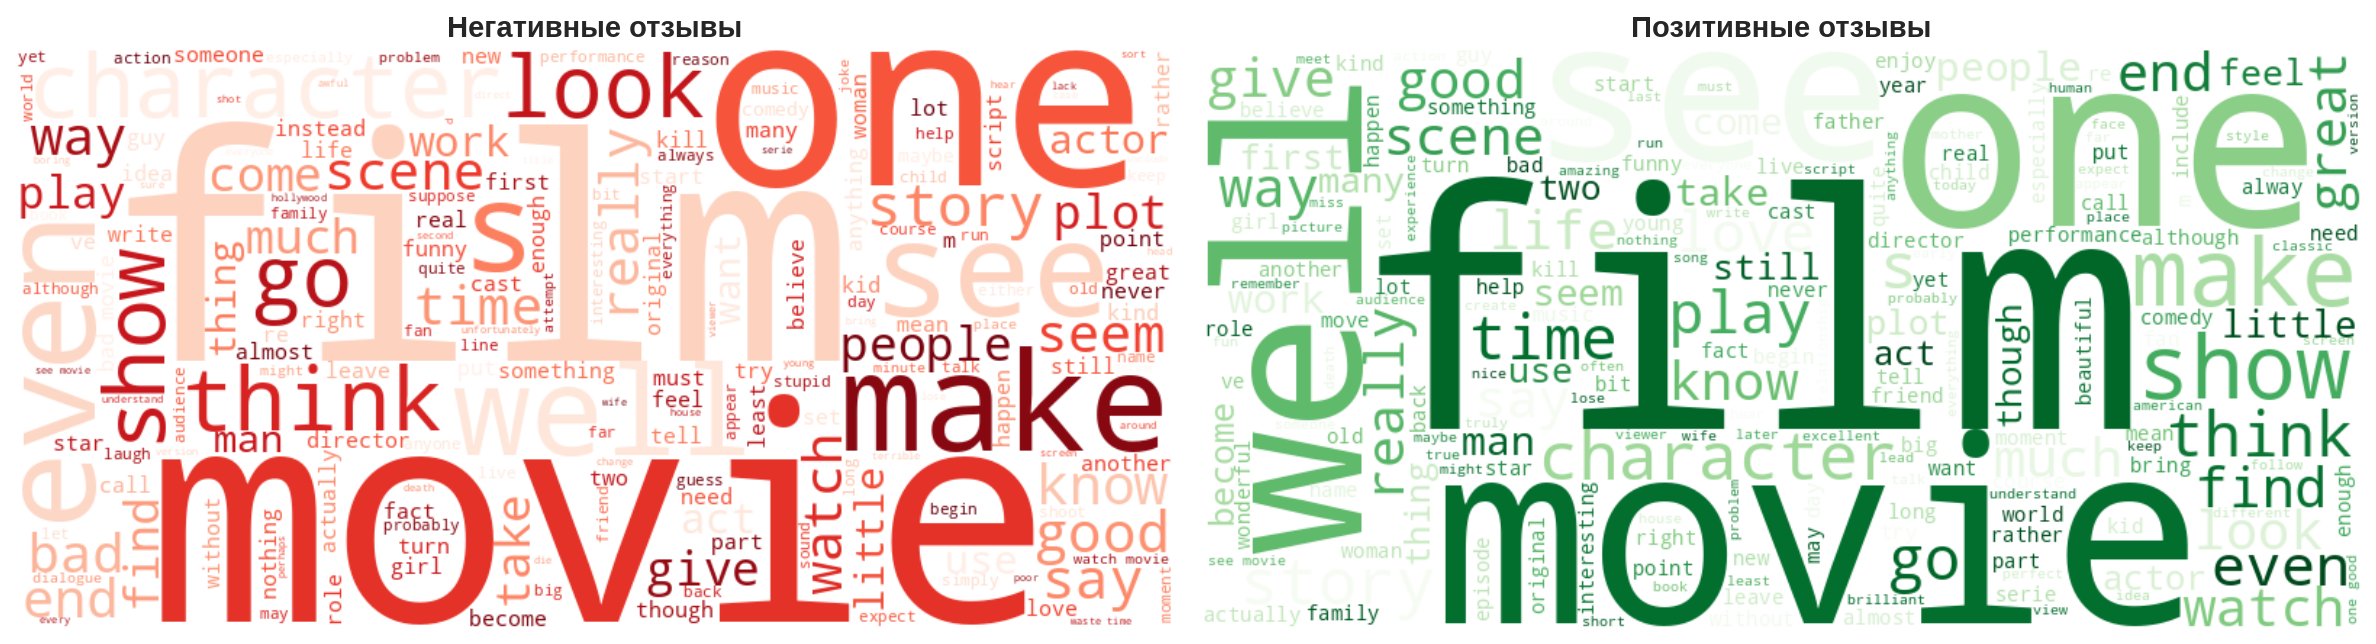

✅ Облака слов сохранены: figure_4_3_wordclouds.png


In [8]:
print("\n" + "="*60)
print("БЛОК 8: ОБЛАКА СЛОВ")
print("="*60)

# Для негативных
wordcloud_neg = WordCloud(width=800, height=400, background_color='white',
                          colormap='Reds').generate(' '.join(negative_words))

# Для позитивных
wordcloud_pos = WordCloud(width=800, height=400, background_color='white',
                          colormap='Greens').generate(' '.join(positive_words))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wordcloud_neg, interpolation='bilinear')
axes[0].set_title('Негативные отзывы', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(wordcloud_pos, interpolation='bilinear')
axes[1].set_title('Позитивные отзывы', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('figure_4_3_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Облака слов сохранены: figure_4_3_wordclouds.png")

###БЛОК 9: TF-IDF ВЕКТОРИЗАЦИЯ

In [9]:
print("\n" + "="*60)
print("БЛОК 9: TF-IDF ВЕКТОРИЗАЦИЯ")
print("="*60)

tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_no_stopwords'])

print(f"Размерность TF-IDF матрицы: {tfidf_matrix.shape}")
print(f"  - строк (отзывов): {tfidf_matrix.shape[0]}")
print(f"  - столбцов (уникальных слов): {tfidf_matrix.shape[1]}")

feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nПримеры слов из словаря TF-IDF:")
for word in feature_names[:10]:
    print(f"  {word}")


БЛОК 9: TF-IDF ВЕКТОРИЗАЦИЯ
Размерность TF-IDF матрицы: (25000, 1000)
  - строк (отзывов): 25000
  - столбцов (уникальных слов): 1000

Примеры слов из словаря TF-IDF:
  able
  absolutely
  across
  act
  acted
  acting
  action
  actor
  actors
  actress


In [10]:
import re
import spacy
from nltk.corpus import stopwords

# Загрузка модели spaCy (выполнить ОДИН РАЗ)
nlp = spacy.load('en_core_web_sm')

# Загрузка стоп-слов NLTK (выполнить ОДИН РАЗ)
stop_words = stopwords.words('english')

def clean_text(text):
    """
    Очистка текста: приведение к нижнему регистру,
    удаление HTML-тегов, пунктуации и спецсимволов
    """
    # Приведение к нижнему регистру
    text = text.lower()

    # Удаление HTML-тегов
    text = re.sub(r'<[^>]+>', '', text)

    # Удаление пунктуации и спецсимволов
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Удаление лишних пробелов
    text = ' '.join(text.split())

    return text

def remove_stopwords(text):
    """
    Удаление стоп-слов из текста
    """
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

def lemmatize_text(text):
    """
    Лемматизация текста с помощью spaCy
    """
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc]
    return ' '.join(lemmas)

###БЛОК 10: ПОИСК ПОХОЖИХ ОТЗЫВОВ

In [11]:
print("\n" + "="*60)
print("БЛОК 10: ПОИСК ПОХОЖИХ ОТЗЫВОВ")
print("="*60)

# Тестовый запрос
test_review = "This movie was terrible and boring"
test_clean = clean_text(test_review)
test_lemmas = lemmatize_text(test_clean)  # ИСПРАВЛЕНО: было lemmatize_text
test_no_stop = remove_stopwords(test_lemmas)

print(f"Тестовый отзыв: {test_review}")
print(f"После обработки: {test_no_stop}")

# Векторизация запроса
test_vector = tfidf_vectorizer.transform([test_no_stop])

# Вычисление сходства
similarities = cosine_similarity(test_vector, tfidf_matrix).flatten()

# Топ-5 похожих отзывов
top_indices = np.argsort(similarities)[::-1][:5]

print(f"\n Топ-5 похожих отзывов из датасета:")
for idx in top_indices:
    print(f"\n  Сходство: {similarities[idx]:.3f}")
    print(f"  Отзыв: {df['text'].iloc[idx][:150]}...")
    print(f"  Метка: {'Negative' if df['label'].iloc[idx] == 0 else 'Positive'}")


БЛОК 10: ПОИСК ПОХОЖИХ ОТЗЫВОВ
Тестовый отзыв: This movie was terrible and boring
После обработки: movie terrible boring

 Топ-5 похожих отзывов из датасета:

  Сходство: 0.529
  Отзыв: The worst movie I have seen in a while. Yeah its fun to fantasize, but if that is what you are looking for, I suggest you see Brewsters Millions. This...
  Метка: Negative

  Сходство: 0.528
  Отзыв: This movie is terrible but it has some good effects....
  Метка: Negative

  Сходство: 0.496
  Отзыв: What a joke. I am watching it on Channel 1 and I think watching paint dry is much more entertaining. What happened to Caspar Van Dien that got him rop...
  Метка: Negative

  Сходство: 0.475
  Отзыв: Horrible film with bits of the Ramones strewn about. Your worse than average 1970's/80's comedy format of the cool kids taking over the school with so...
  Метка: Negative

  Сходство: 0.474
  Отзыв: This film is really terrible. terrible as in it is a waste of 84 minutes of your life. Special effects are so t

###БЛОК 11: ВЫВОДЫ

In [12]:
print("\n" + "="*60)
print("БЛОК 11: ВЫВОДЫ")
print("="*60)

print(f"""
✅ Датасет IMDB Movie Reviews готов для анализа тональности:
  - {len(df)} отзывов на английском языке
  - Сбалансированные классы: {df['label'].value_counts().to_dict()}
  - Средняя длина отзыва: {df['word_count'].mean():.0f} слов
  - TF-IDF матрица: {tfidf_matrix.shape[0]} x {tfidf_matrix.shape[1]}
  - Поиск работает корректно (cosine similarity)

 Датасет готов для:
  - Обучения моделей классификации тональности
  - Анализа эмоциональной окраски текстов
  - Создания систем рекомендаций
""")


БЛОК 11: ВЫВОДЫ

✅ Датасет IMDB Movie Reviews готов для анализа тональности:
  - 25000 отзывов на английском языке
  - Сбалансированные классы: {0: 12500, 1: 12500}
  - Средняя длина отзыва: 234 слов
  - TF-IDF матрица: 25000 x 1000
  - Поиск работает корректно (cosine similarity)

 Датасет готов для:
  - Обучения моделей классификации тональности
  - Анализа эмоциональной окраски текстов
  - Создания систем рекомендаций

